<a href="https://colab.research.google.com/github/salihawouda2003/renal-transcriptomic-analysis/blob/main/renal_transcriptomic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install library
!pip install GEOparse

# Imports
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
# Download the kidney transplant dataset (GSE36059)
gse = GEOparse.get_GEO(geo="GSE36059", destdir="./");

18-Apr-2026 03:07:21 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
18-Apr-2026 03:07:21 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE36nnn/GSE36059/soft/GSE36059_family.soft.gz to ./GSE36059_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE36nnn/GSE36059/soft/GSE36059_family.soft.gz to ./GSE36059_family.soft.gz
100%|██████████| 194M/194M [00:10<00:00, 19.0MB/s]
18-Apr-2026 03:07:33 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
18-Apr-2026 03:07:33 DEBUG downloader - Moving /tmp/tmpeolu1yfp to /content/GSE36059_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpeolu1yfp to /content/GSE36059_family.soft.gz
18-Apr-2026 03:07:33 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE36nnn/GSE36059/soft/GSE36059_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE36nnn/GSE3605

In [5]:
# Create the expression matrix (to define 'data')
data = gse.pivot_samples('VALUE')

In [6]:
# Priority-Based Mapping
sample_names = list(data.columns)
labels_final = []

for sn in sample_names:
    gsm = gse.gsms[sn]
    # Focus only on the diagnosis line
    diag_line = gsm.metadata['characteristics_ch1'][0].lower()

    # Logic: If 'non-rejecting' is the ONLY thing at the end of the string
    if diag_line.endswith('non-rejecting') or diag_line.endswith('stable'):
        labels_final.append('Stable')
    # If it ends with any of our rejection types
    elif any(diag_line.endswith(t) for t in ['tcmr', 'abmr', 'mixed', 'rejection']):
        labels_final.append('Rejection')
    else:
        # If we can't be sure, let's look for the presence of the code
        if 'non-rejecting' in diag_line:
             # Double check: does it say "diagnosis: tcmr" but mentions "non-rejecting" in the header?
             if 'diagnosis: tcmr' in diag_line or 'diagnosis: abmr' in diag_line:
                 labels_final.append('Rejection')
             else:
                 labels_final.append('Stable')
        else:
            labels_final.append('Other')

# Update global labels
labels = labels_final

# Final Clean
clean_data = data.dropna()

print("--- The Dataset Stats ---")
print(f"Rejection Samples: {labels.count('Rejection')}")
print(f"Stable Samples:    {labels.count('Stable')}")
print(f"Other/Excluded:    {labels.count('Other')}")

--- The Dataset Stats ---
Rejection Samples: 122
Stable Samples:    289
Other/Excluded:    0


In [7]:
# Identify indices for each group using the actual column names
# use the columns of clean_data to ensure perfect alignment
rejection_idx = [i for i, label in enumerate(labels) if label == 'Rejection']
stable_idx = [i for i, label in enumerate(labels) if label == 'Stable']

# SAFETY CHECK: Print counts to ensure there are samples in both groups
print(f"Samples in Rejection group: {len(rejection_idx)}")
print(f"Samples in Stable group: {len(stable_idx)}")

# Calculate means using the specific indices
# use .iloc to select columns by their integer position
mean_rejection = clean_data.iloc[:, rejection_idx].mean(axis=1)
mean_stable = clean_data.iloc[:, stable_idx].mean(axis=1)

# Calculate Log2 Fold Change
log2_fc = mean_rejection - mean_stable

# Extract Top 50 and drop any remaining NaNs
top_50_genes = log2_fc.dropna().sort_values(ascending=False).head(50)

print("\n--- TOP 10 BIOMARKERS IDENTIFIED ---")
if top_50_genes.empty:
    print("Warning: Top 50 list is empty. Check if labels match data columns.")
else:
    print(top_50_genes.head(10))

Samples in Rejection group: 122
Samples in Stable group: 289

--- TOP 10 BIOMARKERS IDENTIFIED ---
ID_REF
211122_s_at    2.739844
210163_at      2.382206
203915_at      2.286595
204533_at      2.049447
229390_at      1.857415
229391_s_at    1.613753
210029_at      1.611146
204006_s_at    1.579954
202270_at      1.554863
231577_s_at    1.518534
dtype: float64


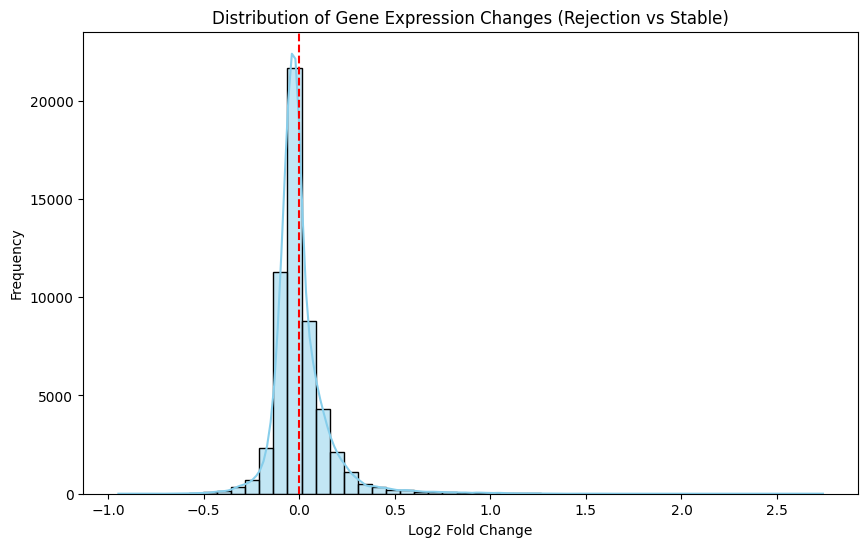

In [8]:
# 10. Visualize the distribution of changes
plt.figure(figsize=(10, 6))
sns.histplot(log2_fc, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Gene Expression Changes (Rejection vs Stable)')
plt.xlabel('Log2 Fold Change')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.savefig('biomarker_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Map Probe IDs to Gene Symbols
# In GEOparse, platform annotations are stored in the .gpls dictionary
gpl = gse.gpls['GPL570']
gene_metadata = gpl.table[['ID', 'Gene Symbol']]

# Create a dictionary for quick lookup
gene_map = dict(zip(gene_metadata['ID'], gene_metadata['Gene Symbol']))

# Apply the map to Top 50 list
top_biomarkers_named = top_50_genes.copy()
top_biomarkers_named.index = [gene_map.get(i, i) for i in top_50_genes.index]

print("--- TOP 10 CLINICAL BIOMARKERS ---")
print(top_biomarkers_named.head(10))

--- TOP 10 CLINICAL BIOMARKERS ---
CXCL11               2.739844
CXCL11               2.382206
CXCL9                2.286595
CXCL10               2.049447
FAM26F               1.857415
FAM26F               1.613753
IDO1                 1.611146
FCGR3A /// FCGR3B    1.579954
GBP1                 1.554863
GBP1                 1.518534
dtype: float64


In [10]:
# 1. Create final_df correctly by handling duplicates
final_df = clean_data.copy()
final_df['Gene Symbol'] = [gene_map.get(i, i) for i in final_df.index]

# COLLAPSE DUPLICATES: If multiple probes map to one gene, take the average
# This prevents the "Incompatible shapes" error
final_df = final_df.groupby('Gene Symbol').mean()

# 2. Define columns using the indices from your previous cell
rejection_cols = clean_data.columns[rejection_idx]
stable_cols = clean_data.columns[stable_idx]

# 3. Initialize the results dataframe
summary_df = pd.DataFrame(index=final_df.index)

# 4. Run the T-test with a safety check
p_values = []
for gene in final_df.index:
    # .values ensures we are passing simple arrays to scipy
    rej_vals = final_df.loc[gene, rejection_cols].values
    sta_vals = final_df.loc[gene, stable_cols].values

    # Independent T-test
    t_stat, p_val = stats.ttest_ind(rej_vals, sta_vals, nan_policy='omit')
    p_values.append(p_val)

summary_df['p_value'] = p_values
summary_df['Log2FC'] = final_df[rejection_cols].mean(axis=1) - final_df[stable_cols].mean(axis=1)
summary_df['-log10_p'] = -np.log10(summary_df['p_value'])



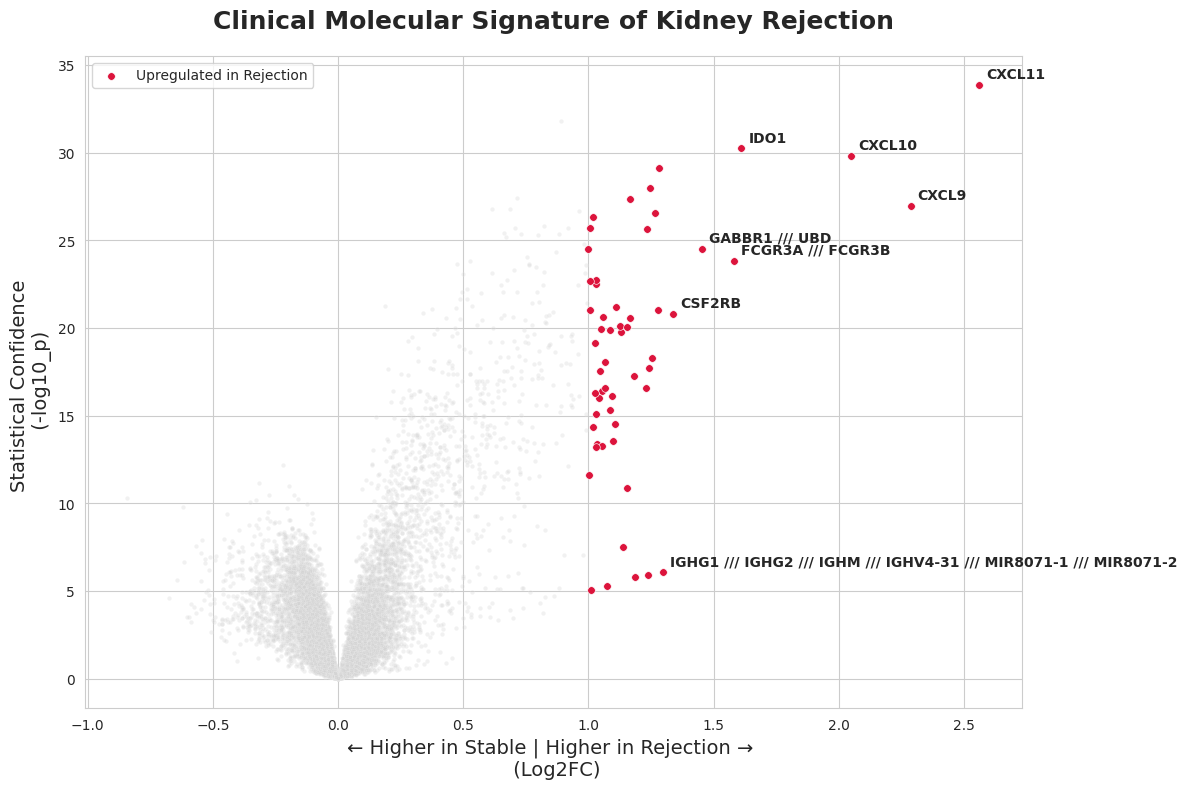

In [11]:
# 1. Set the style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 2. Plotting the background (Non-significant genes)
sns.scatterplot(data=summary_df, x='Log2FC', y='-log10_p',
                color='lightgrey', alpha=0.3, s=10)

# 3. Highlighting the clinical biomarkers
# We'll color genes that are high in rejection red, and low in rejection blue
upregulated = summary_df[(summary_df['p_value'] < 0.05) & (summary_df['Log2FC'] > 1)]
downregulated = summary_df[(summary_df['p_value'] < 0.05) & (summary_df['Log2FC'] < -1)]

sns.scatterplot(data=upregulated, x='Log2FC', y='-log10_p', color='crimson', s=30, label='Upregulated in Rejection')
sns.scatterplot(data=downregulated, x='Log2FC', y='-log10_p', color='royalblue', s=30, label='Downregulated in Rejection')

# 4. Human-Readable Axis Labels
plt.title('Clinical Molecular Signature of Kidney Rejection', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('← Higher in Stable | Higher in Rejection → \n (Log2FC)', fontsize=14)
plt.ylabel('Statistical Confidence \n (-log10_p)', fontsize=14)

# 5. Adding annotations for the top "winners"
# Let's label the top 8 most significant genes
top_genes = summary_df.sort_values('Log2FC', ascending=False).head(8)
for i, row in top_genes.iterrows():
    plt.annotate(i, (row['Log2FC'], row['-log10_p']),
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=10, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.savefig('clinical_volcano_plot.png', dpi=300)
plt.show()

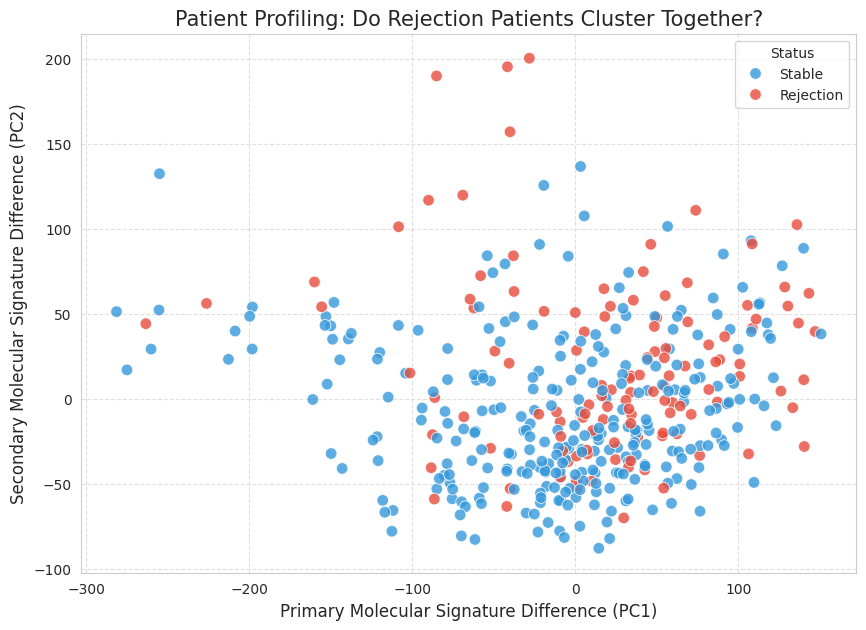

In [12]:
# 1. Prepare data (Patients as rows, Genes as columns)
pca_input = final_df.T
scaled_data = StandardScaler().fit_transform(pca_input)

# 2. Run PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(scaled_data)

# 3. Create Plotting DataFrame
pca_df = pd.DataFrame(data=coords, columns=['PC1', 'PC2'])
pca_df['Status'] = labels # 'Rejection' or 'Stable'

# 4. Plot Patients
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Status',
                palette={'Stable': '#3498db', 'Rejection': '#e74c3c', 'Other': '#95a5a6'},
                s=70, alpha=0.8, edgecolor='w')

plt.title('Patient Profiling: Do Rejection Patients Cluster Together?', fontsize=15)
plt.xlabel('Primary Molecular Signature Difference (PC1)', fontsize=12)
plt.ylabel('Secondary Molecular Signature Difference (PC2)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

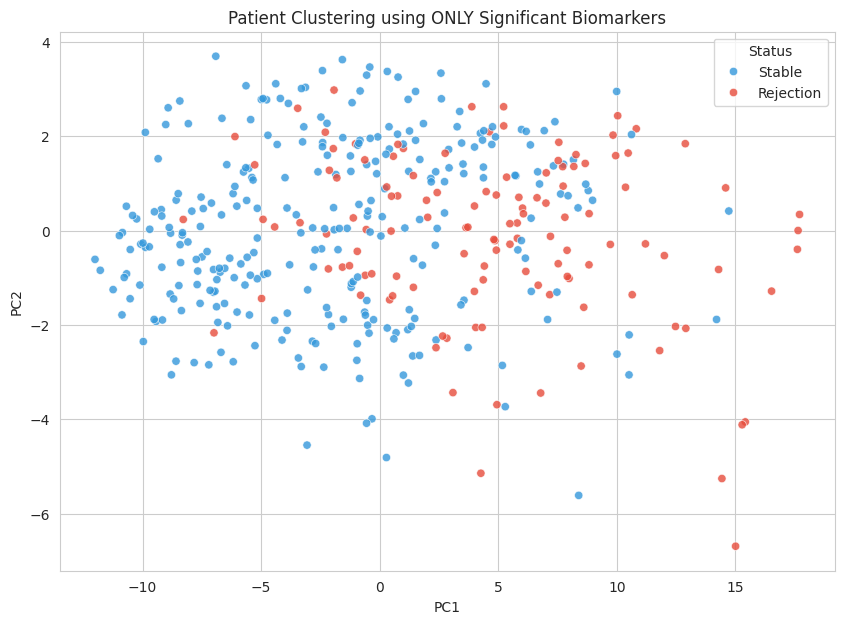

In [13]:
# 1. Use only the genes that were significant in the Volcano Plot
significant_gene_names = summary_df[(summary_df['p_value'] < 0.05) & (abs(summary_df['Log2FC']) > 1)].index

# 2. Filter our data to only include these 'Important' genes
filtered_input = final_df.loc[significant_gene_names].T
scaled_filtered = StandardScaler().fit_transform(filtered_input)

# 3. Re-run PCA on just the biomarkers
pca_filtered = PCA(n_components=2)
coords_filtered = pca_filtered.fit_transform(scaled_filtered)

# 4. Plot again
pca_filtered_df = pd.DataFrame(data=coords_filtered, columns=['PC1', 'PC2'])
pca_filtered_df['Status'] = labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_filtered_df, x='PC1', y='PC2', hue='Status',
                palette={'Stable': '#3498db', 'Rejection': '#e74c3c'}, alpha=0.8)
plt.title('Patient Clustering using ONLY Significant Biomarkers')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


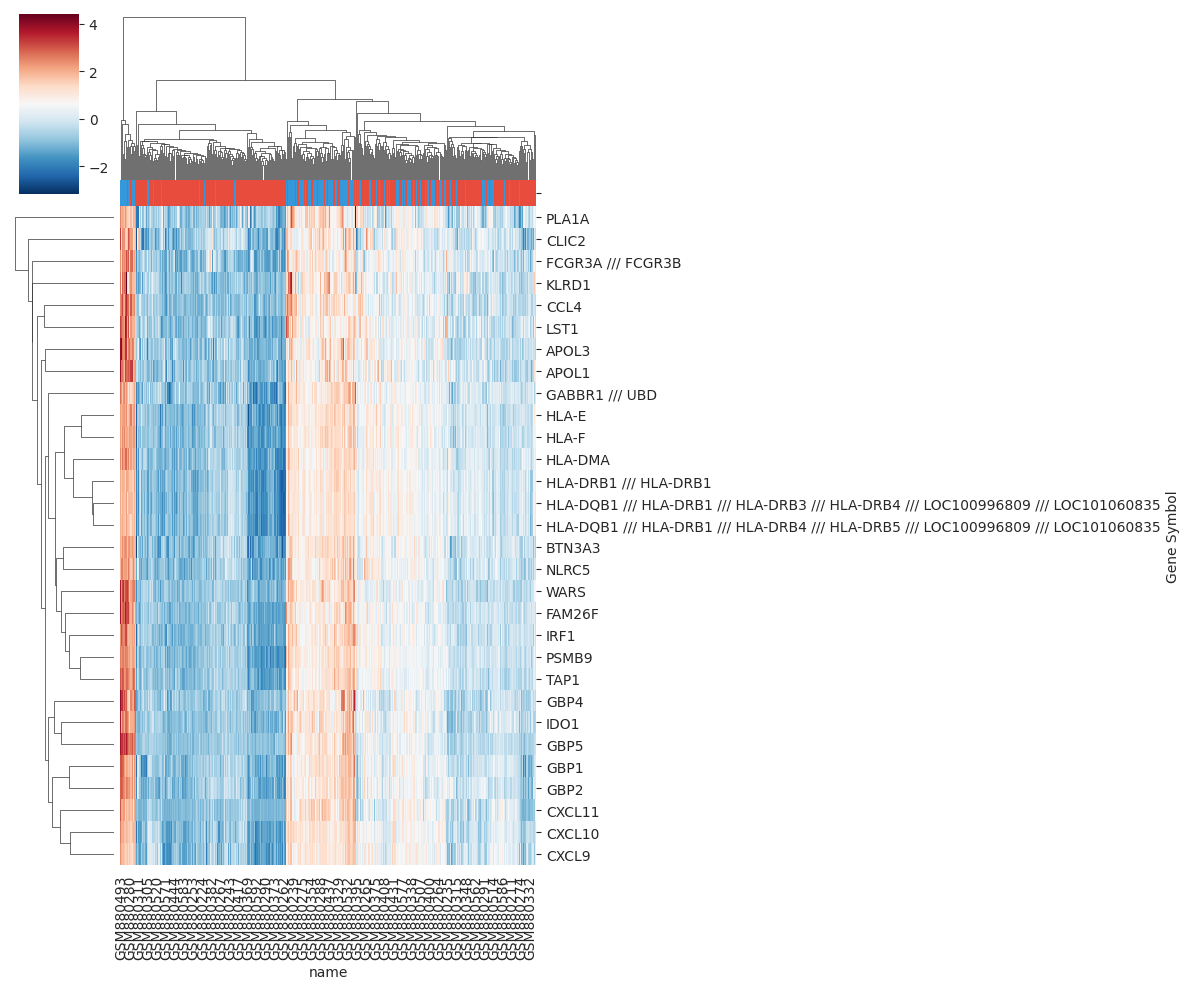

In [14]:
# 1. Select the top 30 most significant genes (for a clean visual)
top_30_genes = summary_df.sort_values('-log10_p', ascending=False).head(30).index
heatmap_data = final_df.loc[top_30_genes]

# 2. Create a color map for the Status (Stable vs Rejection)
# This adds a color bar at the top so you can see which patient is which
lut = dict(zip(set(labels), ['#3498db', '#e74c3c', '#95a5a6']))
col_colors = pd.Series(labels, index=final_df.columns).map(lut)

# 3. Plot the Clustergram
sns.clustermap(heatmap_data,
               z_score=0, # Standardizes the rows
               cmap='RdBu_r', # Red for high expression, Blue for low
               col_colors=col_colors,
               figsize=(12, 10))

plt.show()